Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             confusion_matrix)
import joblib

print("All imports successful!")

All imports successful!


Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/CSE572_Project/'

train_df = pd.read_csv(path + 'train.csv')
val_df   = pd.read_csv(path + 'val.csv')
test_df  = pd.read_csv(path + 'test.csv')
classes  = np.load(path + 'label_classes.npy', allow_pickle=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 1738 | Val: 373 | Test: 373


Skill Keyword List

In [ ]:
# ─── Domain-Specific Keyword Lists ────────────────────
# These are job-category-specific keywords that help
# distinguish between the 24 categories

DOMAIN_KEYWORDS = {
    'finance': ['financial', 'accounting', 'budget', 'audit', 'tax',
                'investment', 'portfolio', 'trading', 'banking', 'revenue',
                'profit', 'loss', 'balance sheet', 'payroll', 'invoice',
                'ledger', 'reconciliation', 'forecasting', 'equity', 'debt'],
    'tech': ['python', 'java', 'sql', 'javascript', 'software', 'developer',
             'programming', 'algorithm', 'database', 'network', 'cloud',
             'api', 'agile', 'devops', 'cybersecurity', 'machine learning',
             'artificial intelligence', 'data science', 'deep learning',
             'backend', 'frontend', 'fullstack', 'infrastructure'],
    'healthcare': ['patient', 'clinical', 'medical', 'hospital', 'nursing',
                   'diagnosis', 'treatment', 'pharmacy', 'surgery', 'health',
                   'doctor', 'physician', 'therapist', 'care', 'medicine',
                   'dental', 'psychiatric', 'rehabilitation', 'emergency',
                   'icu', 'ward', 'prescription', 'vaccination'],
    'legal': ['law', 'legal', 'court', 'attorney', 'advocate', 'litigation',
              'contract', 'compliance', 'regulation', 'judicial', 'counsel',
              'prosecution', 'defense', 'client', 'case', 'verdict',
              'plaintiff', 'defendant', 'statute', 'jurisdiction', 'appeal',
              'arbitration', 'intellectual property', 'corporate law'],
    'education': ['teaching', 'curriculum', 'student', 'classroom',
                  'instruction', 'school', 'university', 'professor',
                  'lecture', 'training', 'education', 'lesson', 'grade',
                  'syllabus', 'pedagogy', 'assessment', 'tutoring',
                  'e-learning', 'academic', 'faculty', 'enrollment'],
    'engineering': ['mechanical', 'electrical', 'civil', 'structural',
                    'design', 'cad', 'manufacturing', 'construction',
                    'blueprint', 'technical', 'engineering', 'project',
                    'autocad', 'solidworks', 'simulation', 'prototype',
                    'quality control', 'tolerance', 'specification',
                    'schematic', 'wiring', 'plumbing', 'surveying'],
    'sales': ['sales', 'revenue', 'target', 'client', 'customer',
              'negotiation', 'pipeline', 'crm', 'lead', 'conversion',
              'quota', 'b2b', 'retail', 'marketing', 'business development',
              'upselling', 'cross-selling', 'prospecting', 'cold calling',
              'account management', 'territory', 'commission', 'closing'],
    'creative': ['design', 'creative', 'art', 'graphic', 'visual',
                 'photography', 'video', 'media', 'brand', 'content',
                 'digital', 'social media', 'advertising', 'campaign',
                 'illustration', 'animation', 'ui', 'ux', 'wireframe',
                 'typography', 'branding', 'editorial', 'copywriting'],
    'hr': ['recruitment', 'hiring', 'onboarding', 'payroll', 'benefits',
           'performance', 'talent', 'workforce', 'employee', 'hr',
           'human resources', 'training', 'development', 'policy',
           'compensation', 'retention', 'engagement', 'appraisal',
           'grievance', 'diversity', 'inclusion', 'staffing'],
    'hospitality': ['chef', 'kitchen', 'restaurant', 'food', 'cooking',
                    'menu', 'catering', 'culinary', 'hospitality', 'recipe',
                    'cuisine', 'beverage', 'service', 'guest', 'hotel',
                    'banquet', 'pastry', 'sommelier', 'bartending',
                    'housekeeping', 'front desk', 'concierge'],
    'aviation': ['pilot', 'aircraft', 'aviation', 'flight', 'airline',
                 'airport', 'navigation', 'airway', 'cabin', 'aerospace',
                 'atc', 'ground', 'safety', 'crew', 'cockpit', 'runway',
                 'turbine', 'airframe', 'maintenance', 'dispatcher',
                 'ifr', 'vfr', 'logbook', 'clearance'],
    'agriculture': ['farming', 'crop', 'soil', 'harvest', 'livestock',
                    'agriculture', 'irrigation', 'pesticide', 'seed',
                    'plantation', 'horticulture', 'agronomy', 'fertilizer',
                    'greenhouse', 'organic', 'dairy', 'poultry', 'forestry',
                    'aquaculture', 'tractor', 'cultivation'],
    'automobile': ['vehicle', 'automotive', 'car', 'engine', 'transmission',
                   'chassis', 'brake', 'suspension', 'tire', 'exhaust',
                   'dealership', 'service advisor', 'mechanic', 'technician',
                   'diagnostic', 'oil change', 'bodywork', 'painting',
                   'fleet', 'driving', 'motor', 'garage', 'workshop'],
    'apparel': ['fashion', 'clothing', 'textile', 'garment', 'fabric',
                'apparel', 'retail', 'merchandise', 'collection', 'trend',
                'styling', 'wardrobe', 'fitting', 'sewing', 'pattern',
                'boutique', 'luxury', 'brand', 'accessories', 'costume'],
    'fitness': ['fitness', 'gym', 'exercise', 'workout', 'training',
                'nutrition', 'diet', 'weight', 'cardio', 'strength',
                'personal trainer', 'yoga', 'pilates', 'crossfit',
                'athlete', 'sports', 'wellness', 'rehabilitation',
                'coaching', 'endurance', 'flexibility'],
    'bpo': ['bpo', 'call center', 'customer service', 'outsourcing',
            'inbound', 'outbound', 'helpdesk', 'support', 'ticketing',
            'escalation', 'sla', 'kpi', 'chat support', 'email support',
            'voice process', 'non-voice', 'process', 'shift', 'queue'],
    'consultant': ['consulting', 'strategy', 'advisory', 'stakeholder',
                   'engagement', 'transformation', 'implementation',
                   'framework', 'methodology', 'deliverable', 'roadmap',
                   'gap analysis', 'best practice', 'change management',
                   'process improvement', 'benchmarking', 'kpi', 'roi',
                   'business case', 'feasibility', 'recommendation'],
    'banking': ['bank', 'loan', 'credit', 'mortgage', 'interest rate',
                'deposit', 'account', 'transaction', 'branch', 'teller',
                'underwriting', 'risk', 'compliance', 'aml', 'kyc',
                'swift', 'wire transfer', 'forex', 'treasury', 'npa'],
    'public_relations': ['pr', 'public relations', 'press release',
                         'media relations', 'communication', 'spokesperson',
                         'reputation', 'crisis', 'stakeholder', 'journalist',
                         'interview', 'publication', 'outreach', 'pitch',
                         'event', 'brand awareness', 'influencer'],
    'digital_media': ['social media', 'content', 'seo', 'sem', 'analytics',
                      'engagement', 'impressions', 'reach', 'influencer',
                      'youtube', 'instagram', 'twitter', 'facebook',
                      'tiktok', 'podcast', 'streaming', 'monetization',
                      'subscriber', 'viral', 'hashtag', 'algorithm']
}

TECHNICAL_SKILLS = [
    'python', 'java', 'sql', 'excel', 'javascript', 'r',
    'machine learning', 'deep learning', 'tensorflow', 'pytorch',
    'aws', 'azure', 'docker', 'kubernetes', 'git', 'linux',
    'tableau', 'power bi', 'hadoop', 'spark', 'scala', 'c++',
    'html', 'css', 'react', 'node', 'django', 'flask',
    'matlab', 'sas', 'spss', 'mongodb', 'postgresql'
]

SOFT_SKILLS = [
    'leadership', 'communication', 'teamwork', 'problem solving',
    'management', 'analytical', 'organization', 'collaboration',
    'presentation', 'negotiation', 'planning', 'coordination',
    'decision making', 'time management', 'critical thinking'
]

EDUCATION_KEYWORDS = {
    'phd': 4, 'ph.d': 4, 'doctorate': 4,
    'master': 3, 'mba': 3, 'm.s': 3, 'msc': 3,
    'bachelor': 2, 'b.s': 2, 'b.a': 2, 'bsc': 2, 'undergraduate': 2,
    'associate': 1, 'diploma': 1, 'certificate': 1
}

print(f"Domain keyword categories: {len(DOMAIN_KEYWORDS)}")
print(f"Technical skills: {len(TECHNICAL_SKILLS)}")
print(f"Soft skills: {len(SOFT_SKILLS)}")
print(f"Education levels: {len(EDUCATION_KEYWORDS)}")

Domain keyword categories: 20
Technical skills: 33
Soft skills: 15
Education levels: 15


Feature extraction function

In [ ]:
# ─── Expanded Feature Extraction Function ──────────────
def extract_features(text):
    text_lower = str(text).lower()
    words = text_lower.split()

    # 1. Resume length features
    word_count = len(words)
    char_count = len(text_lower)

    # 2. Technical skill count
    tech_skill_count = sum(
        1 for skill in TECHNICAL_SKILLS if skill in text_lower
    )

    # 3. Soft skill count
    soft_skill_count = sum(
        1 for skill in SOFT_SKILLS if skill in text_lower
    )

    # 4. Years of experience
    year_patterns = re.findall(
        r'(\d+)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:experience)?',
        text_lower
    )
    years_exp = max([int(y) for y in year_patterns], default=0)
    years_exp = min(years_exp, 40)

    # 5. Education level
    edu_level = 0
    for keyword, level in EDUCATION_KEYWORDS.items():
        if keyword in text_lower:
            edu_level = max(edu_level, level)

    # 6. Unique technical skills
    unique_tech = len(set(
        skill for skill in TECHNICAL_SKILLS if skill in text_lower
    ))

    # 7. Domain keyword scores — one score per domain
    domain_scores = {}
    for domain, keywords in DOMAIN_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text_lower)
        domain_scores[f'domain_{domain}'] = score

    # Combine all features
    features = {
        'word_count': word_count,
        'char_count': char_count,
        'tech_skill_count': tech_skill_count,
        'soft_skill_count': soft_skill_count,
        'years_experience': years_exp,
        'education_level': edu_level,
        'unique_tech_skills': unique_tech,
    }
    features.update(domain_scores)

    return features

# Test on sample
sample = train_df['text'].iloc[0]
result = extract_features(sample)
print(f"Total features extracted: {len(result)}")
print("\nSample feature values:")
for k, v in result.items():
    print(f"  {k}: {v}")

Total features extracted: 27

Sample feature values:
  word_count: 504
  char_count: 4066
  tech_skill_count: 2
  soft_skill_count: 1
  years_experience: 0
  education_level: 3
  unique_tech_skills: 2
  domain_finance: 1
  domain_tech: 0
  domain_healthcare: 2
  domain_legal: 1
  domain_education: 9
  domain_engineering: 1
  domain_sales: 7
  domain_creative: 3
  domain_hr: 5
  domain_hospitality: 2
  domain_aviation: 0
  domain_agriculture: 0
  domain_automobile: 0
  domain_apparel: 1
  domain_fitness: 1
  domain_bpo: 3
  domain_consultant: 0
  domain_banking: 3
  domain_public_relations: 3
  domain_digital_media: 1


Extracting features for all splits

In [ ]:
print("Extracting features for training set...")
train_features = pd.DataFrame(
    train_df['text'].apply(extract_features).tolist()
)

print("Extracting features for validation set...")
val_features = pd.DataFrame(
    val_df['text'].apply(extract_features).tolist()
)

print("Extracting features for test set...")
test_features = pd.DataFrame(
    test_df['text'].apply(extract_features).tolist()
)

print(f"\nFeature matrix shapes:")
print(f"  Train: {train_features.shape}")
print(f"  Val:   {val_features.shape}")
print(f"  Test:  {test_features.shape}")

print(f"\nFeature summary (train):")
print(train_features.describe().round(2))

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...

Feature matrix shapes:
  Train: (1738, 27)
  Val:   (373, 27)
  Test:  (373, 27)

Feature summary (train):
       word_count  char_count  tech_skill_count  soft_skill_count  \
count     1738.00     1738.00           1738.00           1738.00   
mean       604.29     4927.55              2.31              4.11   
std        260.80     2141.19              1.35              2.06   
min         84.00      572.00              1.00              0.00   
25%        490.25     3984.50              2.00              3.00   
50%        566.00     4626.00              2.00              4.00   
75%        697.00     5723.75              3.00              5.00   
max       2950.00    24354.00             16.00             12.00   

       years_experience  education_level  unique_tech_skills  domain_finance  \
count           1738.00          1738.00             1738.00         173

Training XGBoost classifier

In [ ]:
y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

print("Training XGBoost classifier...")
xgb.fit(
    train_features, y_train,
    eval_set=[(val_features, y_val)],
    verbose=50
)

val_preds = xgb.predict(val_features)

print("\n=== Structured Skill Agent XGBoost (Validation) ===")
print(f"Accuracy:    {accuracy_score(y_val, val_preds):.4f}")
print(f"Macro F1:    {f1_score(y_val, val_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.4f}")
print("\nPer-class report:")
print(classification_report(y_val, val_preds,
                            target_names=classes,
                            zero_division=0))

Training XGBoost classifier...
[0]	validation_0-mlogloss:2.97669
[50]	validation_0-mlogloss:1.94244
[82]	validation_0-mlogloss:1.94732

=== Structured Skill Agent XGBoost (Validation) ===
Accuracy:    0.4424
Macro F1:    0.4028
Weighted F1: 0.4305

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.41      0.39      0.40        18
              ADVOCATE       0.25      0.22      0.24        18
           AGRICULTURE       0.50      0.33      0.40         9
               APPAREL       0.46      0.40      0.43        15
                  ARTS       0.24      0.27      0.25        15
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       1.00      0.53      0.69        17
               BANKING       0.45      0.59      0.51        17
                   BPO       0.00      0.00      0.00         3
  BUSINESS-DEVELOPMENT       0.33      0.44      0.38        18
                  CHEF      

Feature importance plot

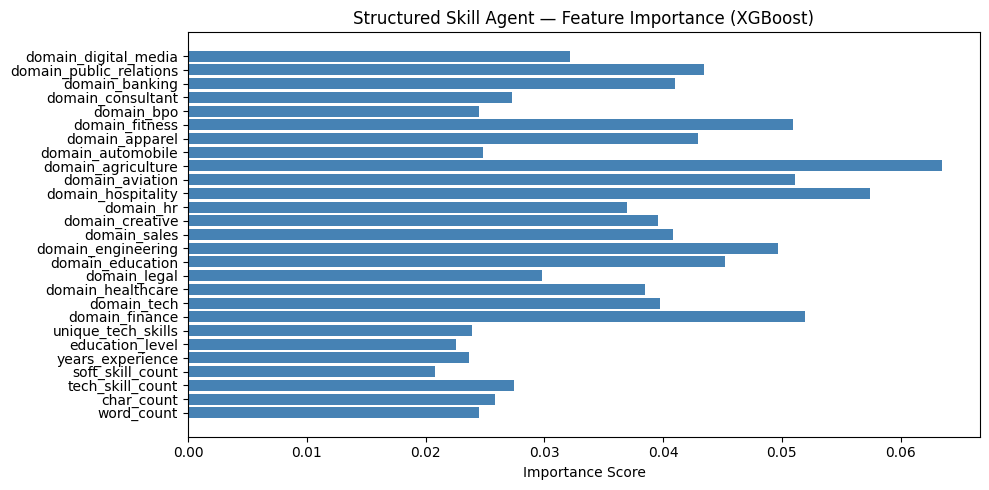

In [ ]:
feature_names = train_features.columns.tolist()
importances = xgb.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Structured Skill Agent — Feature Importance (XGBoost)')
plt.tight_layout()
plt.savefig(path + 'structured_feature_importance.png', dpi=150)
plt.show()

Confusion matrix

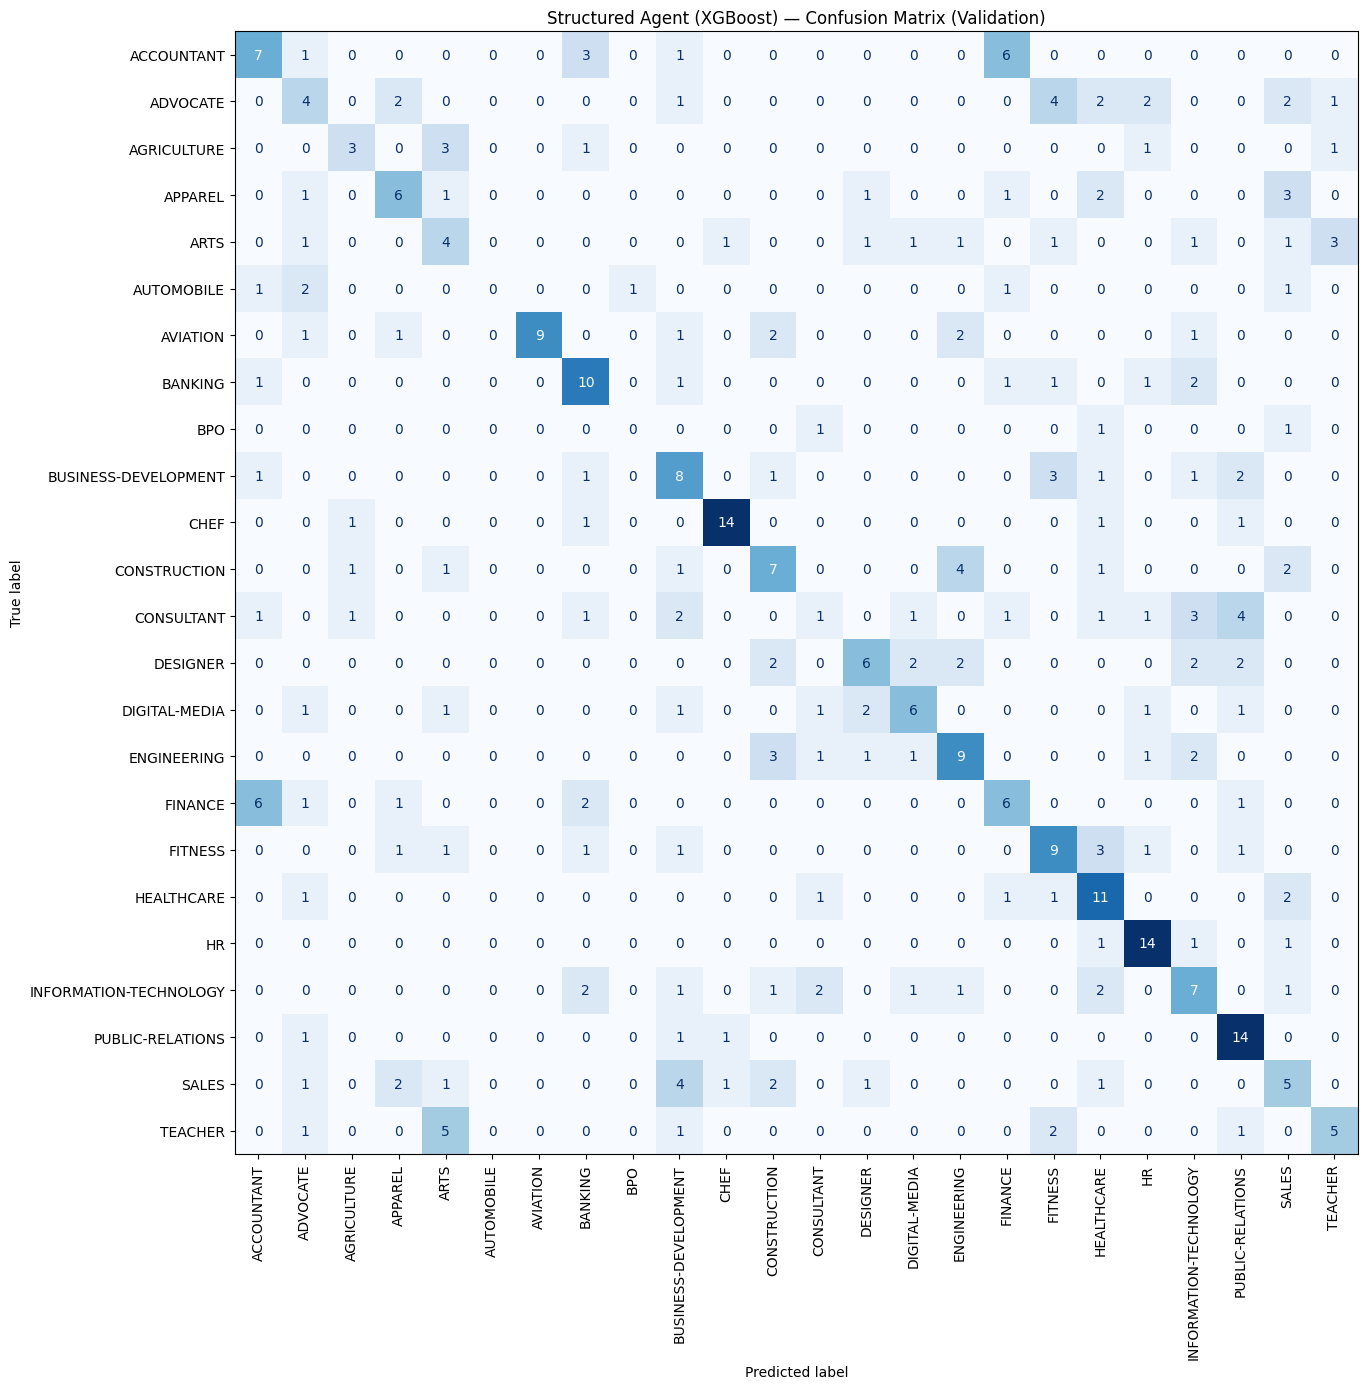

In [ ]:
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=classes)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
ax.set_title('Structured Agent (XGBoost) — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(path + 'structured_confusion_matrix.png', dpi=150)
plt.show()

Test evaluation & save

In [ ]:
test_preds = xgb.predict(test_features)

print("=== Structured Skill Agent XGBoost (Test Set - Final) ===")
print(f"Accuracy:    {accuracy_score(y_test, test_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, test_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, test_preds, average='weighted'):.4f}")

# Save model and features
joblib.dump(xgb, path + 'structured_xgb.pkl')

# Save probability outputs for fusion agent
train_proba = xgb.predict_proba(train_features)
val_proba   = xgb.predict_proba(val_features)
test_proba  = xgb.predict_proba(test_features)

np.save(path + 'structured_train_proba.npy', train_proba)
np.save(path + 'structured_val_proba.npy',   val_proba)
np.save(path + 'structured_test_proba.npy',  test_proba)

# Save feature matrices for reference
train_features.to_csv(path + 'structured_train_features.csv', index=False)
val_features.to_csv(path + 'structured_val_features.csv', index=False)
test_features.to_csv(path + 'structured_test_features.csv', index=False)

print("\nSaved:")
print("  structured_xgb.pkl")
print("  structured_train/val/test_proba.npy")
print("  structured_train/val/test_features.csv")

=== Structured Skill Agent XGBoost (Test Set - Final) ===
Accuracy:    0.4879
Macro F1:    0.4550
Weighted F1: 0.4744

Saved:
  structured_xgb.pkl
  structured_train/val/test_proba.npy
  structured_train/val/test_features.csv
